In [3]:
# ติดตั้ง OpenCV
!pip install -q opencv-python-headless

#ระบบค้นหาโดรนฝูงบิน Match Template Technique

In [16]:
def display_drone_result(image, title="Drone Analysis"):
    if image is None:
        print(f"❌ ไม่พบภาพสำหรับหัวข้อ: {title}")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

🔄 กำลังเริ่มระบบค้นหาโดรนเป้าหมาย...


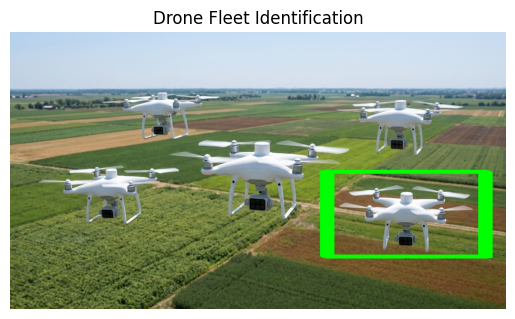

In [17]:
print("🔄 [SYSTEM] กำลังเริ่มระบบ: ชุดรหัสค้นหา พิกัดลงจอด...")
drone_view_path = "main_image.png"
target_pad_path = "template_image.png"

drone_view = cv2.imread(drone_view_path)
target_pad = cv2.imread(target_pad_path)

if drone_view is None or target_pad is None:
    print(f"❌ Error: ข้อมูลพิกัดภาพ {drone_view_path} หรือ {target_pad_path} สูญหาย")
else:
    drone_gray = cv2.cvtColor(drone_view, cv2.COLOR_BGR2GRAY)
    target_gray = cv2.cvtColor(target_pad, cv2.COLOR_BGR2GRAY)
    t_height, t_width = target_gray.shape

    result = cv2.matchTemplate(drone_gray, target_gray, cv2.TM_CCOEFF_NORMED)
    threshold = 0.7
    locations = np.where(result >= threshold)

    match_img = drone_view.copy()
    for pt in zip(*locations[::-1]):
        cv2.rectangle(match_img, pt, (pt[0] + t_width, pt[1] + t_height), (0, 255, 0), 2)

    display_drone_result(match_img, title="Module 1: Landing & Fleet Identification")

#Harr Cascase

##สแกนดวงหน้า ค้นหาบุคคลHaar Cascade สำหรับ Drone

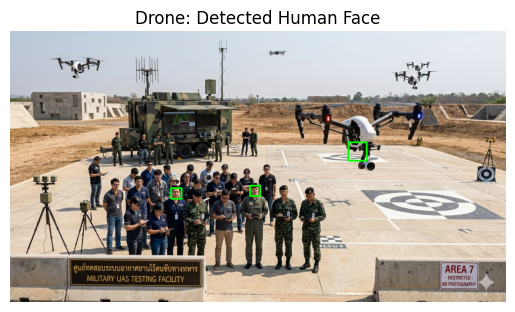

In [12]:
print("\n🔄 [SYSTEM] กำลังเริ่มระบบ: สแกนดวงหน้า ค้นหาบุคคล...")
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

drone_frame = cv2.imread("object.png")

if drone_frame is None:
    print("❌ Error: ไม่พบสัญญาณภาพ object.png สำหรับการสแกนใบหน้า")
else:
    gray_frame = cv2.cvtColor(drone_frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))

    for (x, y, w, h) in faces:
        cv2.rectangle(drone_frame, (x, y), (x + w, y + h), (0, 255, 0), 3)

        roi_gray = gray_frame[y:y+h, x:x+w]
        roi_color = drone_frame[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10)
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)

    display_drone_result(drone_frame, title="Module 2: Human Face & Eye Analysis")

##Drone: ตรวจจับดวงตาและใบหน้าพร้อมกัน Combined Detection

In [3]:
import cv2
import matplotlib.pyplot as plt

# โหลด Cascades (คงเดิม)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

drone_frame = cv2.imread("drone_face_capture.jpg")
gray_frame = cv2.cvtColor(drone_frame, cv2.COLOR_BGR2GRAY)

# ตรวจจับใบหน้าหลัก
target_faces = face_cascade.detectMultiScale(gray_frame, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

for (x, y, w, h) in target_faces:
    # วาดกรอบสีเขียวให้ใบหน้า
    cv2.rectangle(drone_frame, (x, y), (x + w, y + h), (0, 255, 0), 3)

    # กำหนดเขตพื้นที่สนใจ (ROI) ของโดรน เพื่อประมวลผลดวงตาต่อ
    drone_roi_gray = gray_frame[y:y + h, x:x + w]
    drone_roi_color = drone_frame[y:y + h, x:x + w]

    # ตรวจจับดวงตาในพื้นที่ ROI
    target_eyes = eye_cascade.detectMultiScale(drone_roi_gray, scaleFactor=1.3, minNeighbors=10)

    for (ex, ey, ew, eh) in target_eyes:
        cv2.rectangle(drone_roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)

display_drone_view(drone_frame, title="Drone Multi-Target Scanning")

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


# วิเคราะห์วัตถุ ระบุเป้าหมายในสนามรบ





In [ ]:
# # ติดตั้ง OpenCV หากยังไม่ได้ติดตั้ง
# !pip -q install opencv-python

# # ดาวน์โหลดไฟล์ YOLO Model และ Class Labels (หากยังไม่มี)
# !wget -q https://pjreddie.com/media/files/yolov3.weights
# !wget -q https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
# !wget -q https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true -O coco.names


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ✅ ขั้นแรก: สร้างฟังก์ชันแสดงผลไว้ก่อนเพื่อเรียกใช้
def display_battlefield_image(image, title="Battlefield Analysis"):
    if image is None:
        print("❌ [ERROR] สัญญาณภาพว่างเปล่า ไม่สามารถแสดงผลได้")
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()

print("🔄 [SYSTEM] กำลังเตรียมความพร้อมระบบวิเคราะห์วัตถุ YOLO...")

# ดาวน์โหลดไฟล์โมเดล (ตรวจสอบเฉพาะไฟล์ที่ขาด)
if not os.path.exists("yolov3.weights"):
    print("📥 กำลังดาวน์โหลดฐานข้อมูลยุทธวิธี (Weights)...")
    !wget -q https://pjreddie.com/media/files/yolov3.weights
    !wget -q https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
    !wget -q https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true -O coco.names

# โหลดโมเดลและตั้งค่าโครงข่ายประสาทเทียม
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
colors = np.random.uniform(0, 255, size=(len(classes), 3))

# โหลดภาพตรวจการณ์ (ต้องชื่อ object.png ตามที่คุณอัพโหลด)
image_path = "object.png"
image = cv2.imread(image_path)

if image is None:
    print(f"❌ [CRITICAL] ไม่พบสัญญาณภาพจากพิกัด: {image_path}")
else:
    height, width, _ = image.shape
    print(f"📡 วิเคราะห์สัญญาณภาพขนาด: {width}x{height} px")

    # แปลงภาพเข้าสู่ระบบ AI
    blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outputs = net.forward(output_layers)

    class_ids, confidences, boxes = [], [], []

    for output in outputs:
        for detection in output:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]

            # ตรวจจับเฉพาะเป้าหมายที่ความมั่นใจสูงกว่า 50%
            if confidence > 0.5:
                center_x, center_y = int(detection[0] * width), int(detection[1] * height)
                w, h = int(detection[2] * width), int(detection[3] * height)
                x, y = int(center_x - w / 2), int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # กรองการตรวจจับซ้ำ (Non-Maximum Suppression)
    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    # กระบวนการวาดกรอบล็อกเป้าหมาย (Locked On)
    if len(indexes) > 0:
        print(f"🎯 ตรวจพบเป้าหมายสำคัญ {len(indexes.flatten())} รายการ")
        for i in indexes.flatten():
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])

            # ✅ คัดกรองเป้าหมายยุทธศาสตร์: คน, รถ, หรือวัตถุบิน (ที่ AI อาจเห็นเป็นเครื่องบิน/นก)
            if label in ["person", "car", "truck", "bus", "aeroplane", "bird"]:
                confidence = confidences[i]
                color = colors[class_ids[i]]

                # วาดกรอบเป้าหมาย (สีตามคลาสวัตถุ)
                cv2.rectangle(image, (x, y), (x + w, y + h), color, 5)

                # ข้อความสถานะการล็อกเป้า
                text = f"LOCKED: {label.upper()} {confidence*100:.1f}%"
                cv2.putText(image, text, (x, y - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            else:
                continue

    # แสดงผลหน้าจอสั่งการ
    display_battlefield_image(image, title="Module 3: Battlefield Target Identification")

    # บันทึกข้อมูลภารกิจลงในไฟล์
    output_path = "mission_scan_result.jpg"
    cv2.imwrite(output_path, image)
    print(f"✅ [SUCCESS] บันทึกรายงานผลวิเคราะห์ที่: {output_path}")

🔄 [SYSTEM] กำลังเตรียมความพร้อมระบบวิเคราะห์วัตถุ YOLO...
📥 กำลังดาวน์โหลดฐานข้อมูลยุทธวิธี (Weights)...
❌ [CRITICAL] ไม่พบสัญญาณภาพจากพิกัด: object.png


In [ ]:
# โหลดโมเดล YOLO
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

# โหลดชื่อคลาส
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

# ดึงชื่อของเลเยอร์เอาต์พุต
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]


In [ ]:
# ตั้งค่าสีสุ่มสำหรับแต่ละคลาส
colors = np.random.uniform(0, 255, size=(len(classes), 3))

# โหลดภาพ
image = cv2.imread("object.png")  # แทนที่ด้วย path ของภาพ
height, width, _ = image.shape

In [ ]:
# แปลงภาพให้อยู่ในรูปแบบที่ YOLO ต้องการ
blob = cv2.dnn.blobFromImage(image, scalefactor=0.00392, size=(416, 416), mean=(0, 0, 0), swapRB=True, crop=False)
net.setInput(blob)


In [24]:
# ประมวลผลโมเดล
outputs = net.forward(output_layers)

# เก็บข้อมูลที่ตรวจจับได้
class_ids = []
confidences = []
boxes = []

# ประมวลผลเอาต์พุต
for output in outputs:
    for detection in output:
        scores = detection[5:]  # ข้ามค่าที่เกี่ยวกับตำแหน่ง
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        # ตรวจจับเฉพาะผลลัพธ์ที่มีความมั่นใจสูง
        if confidence > 0.5:
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)

            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)


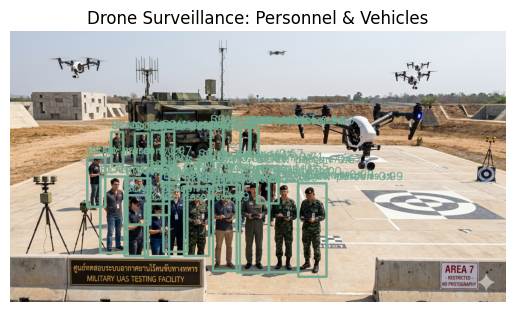

In [22]:
# ใช้ Non-Maximum Suppression เพื่อลดการซ้อนทับ
indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# วาดกรอบและชื่อคลาส
if len(indexes) > 0:
    for i in indexes.flatten():
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])

        # ✅ แก้: เงื่อนไขกรองเฉพาะ คน และ รถรุ่นต่างๆ
        if label in ["person", "car", "truck", "bus"]:
            confidence = confidences[i]
            color = colors[class_ids[i]]

            # วาดกรอบสี่เหลี่ยม (ความหนา 5 เพื่อให้เห็นชัดจากมุมสูง)
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 5)

            # ✅ แก้: เปลี่ยนชื่อ Label ให้ดูเป็นระบบโดรนตรวจการณ์
            cv2.putText(image, f"SCAN: {label} {confidence:.2f}",
                        (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
        else:
            # ถ้าเป็นวัตถุอื่น (เช่น ถังขยะ, ม้านั่ง) ให้ข้ามไป ไม่ต้องวาดกรอบ
            continue

# --- จากนั้นก็ตามด้วยฟังก์ชันแสดงภาพด้านล่าง ---
display_image(image, title="Drone Surveillance: Personnel & Vehicles")


In [23]:
# Save
output_path = "output_image.jpg"
cv2.imwrite(output_path, image)
print(f"Image saved as {output_path}")

Image saved as output_image.jpg
